In [1]:
using Pkg
Pkg.activate(; temp=true)

  Activating new project at `/tmp/jl_Dr1S1O`


In [3]:
Pkg.add(url = "https://github.com/JuliaGeometry/DelaunayTriangulation.jl");
Pkg.add(["CairoMakie"]);

using DelaunayTriangulation


    Updating git-repo `https://github.com/JuliaGeometry/DelaunayTriangulation.jl`
   Resolving package versions...
  No Changes to `/tmp/jl_Dr1S1O/Project.toml`
  No Changes to `/tmp/jl_Dr1S1O/Manifest.toml`
   Resolving package versions...
    Updating `/tmp/jl_Dr1S1O/Project.toml`
  [13f3f980] + CairoMakie v0.12.5
    Updating `/tmp/jl_Dr1S1O/Manifest.toml`
  [621f4979] + AbstractFFTs v1.5.0
  [1520ce14] + AbstractTrees v0.4.5
  [79e6a3ab] + Adapt v4.0.4
  [66dad0bd] + AliasTables v1.1.3
  [27a7e980] + Animations v0.4.1
  [67c07d97] + Automa v1.0.4
  [13072b0f] + AxisAlgorithms v1.1.0
  [39de3d68] + AxisArrays v0.4.7
  [fa961155] + CEnum v0.5.0
  [159f3aea] + Cairo v1.0.5
  [13f3f980] + CairoMakie v0.12.5
  [49dc2e85] + Calculus v0.5.1
  [d360d2e6] + ChainRulesCore v1.24.0
  [a2cac450] + ColorBrewer v0.4.0
  [35d6a980] + ColorSchemes v3.26.0
  [3da002f7] + ColorTypes v0.11.5
  [c3611d14] + ColorVectorSpace v0.10.0
  [5ae59095] + Colors v0.12.11
  [34da2185] + Compat v4.15.0
  [187b05

In [4]:
# Unconstrained
points = rand(2, 50)
tri1 = triangulate(points)

Delaunay Triangulation.
   Number of vertices: 50
   Number of triangles: 89
   Number of edges: 138
   Has boundary nodes: false
   Has ghost triangles: true
   Curve-bounded: false
   Weighted: false
   Constrained: false

In [5]:
# Voronoi example
vorn2 = voronoi(tri1)

Voronoi Tessellation.
    Number of generators: 50
    Number of polygon vertices: 89
    Number of polygons: 50

In [6]:
# Clipped Voronoi
vorn3 = voronoi(tri1, clip=true)

Voronoi Tessellation.
    Number of generators: 50
    Number of polygon vertices: 121
    Number of polygons: 50

In [7]:
# Smoothed Voronoi
vorn4 = centroidal_smooth(vorn3)

Voronoi Tessellation.
    Number of generators: 50
    Number of polygon vertices: 124
    Number of polygons: 50

In [8]:
# Constrained example with refinement
boundary_points = [(0.0, 0.0), (1.0, 0.0), (1.0, 0.3), (0.5, 0.3),
    (0.3, 0.7), (0.1, 1.0), (0.0, 1.0), (0.0, 0.0)]
boundary_nodes, points = convert_boundary_points_to_indices(boundary_points)
tri5 = triangulate(points; boundary_nodes)
refine!(tri5; max_area=1e-2get_area(tri5))

Delaunay Triangulation.
   Number of vertices: 95
   Number of triangles: 150
   Number of edges: 244
   Has boundary nodes: true
   Has ghost triangles: true
   Curve-bounded: false
   Weighted: false
   Constrained: true

In [9]:
# Disjoint constrained example with refinement
boundary_points = [
    [[(0.0, 0.0), (1.0, 0.0), (1.0, 1.0), (0.0, 1.0), (0.0, 0.0)]],
    [[(0.3, 0.3), (0.3, 0.7), (0.7, 0.7), (0.7, 0.3), (0.3, 0.3)]],
    [[(1.2, 0.0), (1.4, 0.0), (1.4, 1.2), (0.0, 1.2), (0.0, 1.1),
        (1.1, 1.1), (1.1, 0.0), (1.2, 0.0)]]
]
boundary_nodes, points = convert_boundary_points_to_indices(boundary_points)
tri6 = triangulate(points; boundary_nodes)
refine!(tri6; max_area=1e-2get_area(tri6))

Delaunay Triangulation.
   Number of vertices: 117
   Number of triangles: 153
   Number of edges: 269
   Has boundary nodes: true
   Has ghost triangles: true
   Curve-bounded: false
   Weighted: false
   Constrained: true

In [10]:
# Curve-bounded example
using DelaunayTriangulation: EllipticalArc
ellipse = EllipticalArc((1.0, 0.0), (1.0, 0.0), (0.0, 0.0), 1.0, 2.0, 0.0)
tri7 = triangulate(NTuple{2,Float64}[]; boundary_nodes=[ellipse])
refine!(tri7; max_area=1e-2get_area(tri7))

Delaunay Triangulation.
   Number of vertices: 108
   Number of triangles: 184
   Number of edges: 291
   Has boundary nodes: true
   Has ghost triangles: true
   Curve-bounded: true
   Weighted: false
   Constrained: true

In [11]:
# Disjoint curve-bounded example
ellipse = EllipticalArc((7.0, 3.5), (7.0, 3.5), (0.0, 3.5), 7.0, 10.0, 0.0)
catmull_cp = [(0.0, 0.0), (-2.0, -1.0), (-4.0, 0.0), (-5.0, 2.0), (-1.0, 4.0), (0.0, 3.0),
    (1.0, 4.0), (5.0, 2.0), (4.0, 0.0), (2.0, -1.0), (0.0, 0.0)]
catmull_spl = CatmullRomSpline(catmull_cp)
circle = CircularArc((0.5, 1.5), (0.5, 1.5), (0.0, 1.0))
circle2 = CircularArc((0.1, 1.5), (0.1, 1.5), (0.0, 1.0), positive=false)
points = [(-4.0, -10.0), (4.0, -10.0), (4.0, -7.0), (-4.0, -7.0)]
square = [1, 2, 3, 4, 1]
boundary_nodes = [[square], [[ellipse]], [[catmull_spl]], [[circle]], [[circle2]]]
tri8 = triangulate(points; boundary_nodes)
refine!(tri8; max_area=1e-2get_area(tri8)) # could also use find_polygon to help define a custom refinement function for each shape

Delaunay Triangulation.
   Number of vertices: 201
   Number of triangles: 303
   Number of edges: 503
   Has boundary nodes: true
   Has ghost triangles: true
   Curve-bounded: true
   Weighted: false
   Constrained: true

In [12]:
using CairoMakie

In [13]:
# Plotting
fig = Figure(fontsize = 42, size = (2800, 1480))
ax = Axis(fig[1, 1], title="Unconstrained", width=600,height=600);
triplot!(ax, tri1);

ax = Axis(fig[1, 2], title="Voronoi", width=600,height=600);
voronoiplot!(ax, vorn2);

ax = Axis(fig[1, 3], title="Clipped Voronoi", width=600,height=600);
voronoiplot!(ax, vorn3);

ax = Axis(fig[1, 4], title="Centroidal Voronoi", width=600,height=600);
voronoiplot!(ax, vorn4);

ax = Axis(fig[2, 1], title="Constrained", width=600,height=600);
triplot!(ax, tri5);

ax = Axis(fig[2, 2], title="Disjoint Constrained", width=600,height=600);
triplot!(ax, tri6);

ax = Axis(fig[2, 3], title="Curve-Bounded", width=600,height=600);
triplot!(ax, tri7);

ax = Axis(fig[2, 4], title="Disjoint Curve-Bounded", width=600,height=600);
triplot!(ax, tri8);


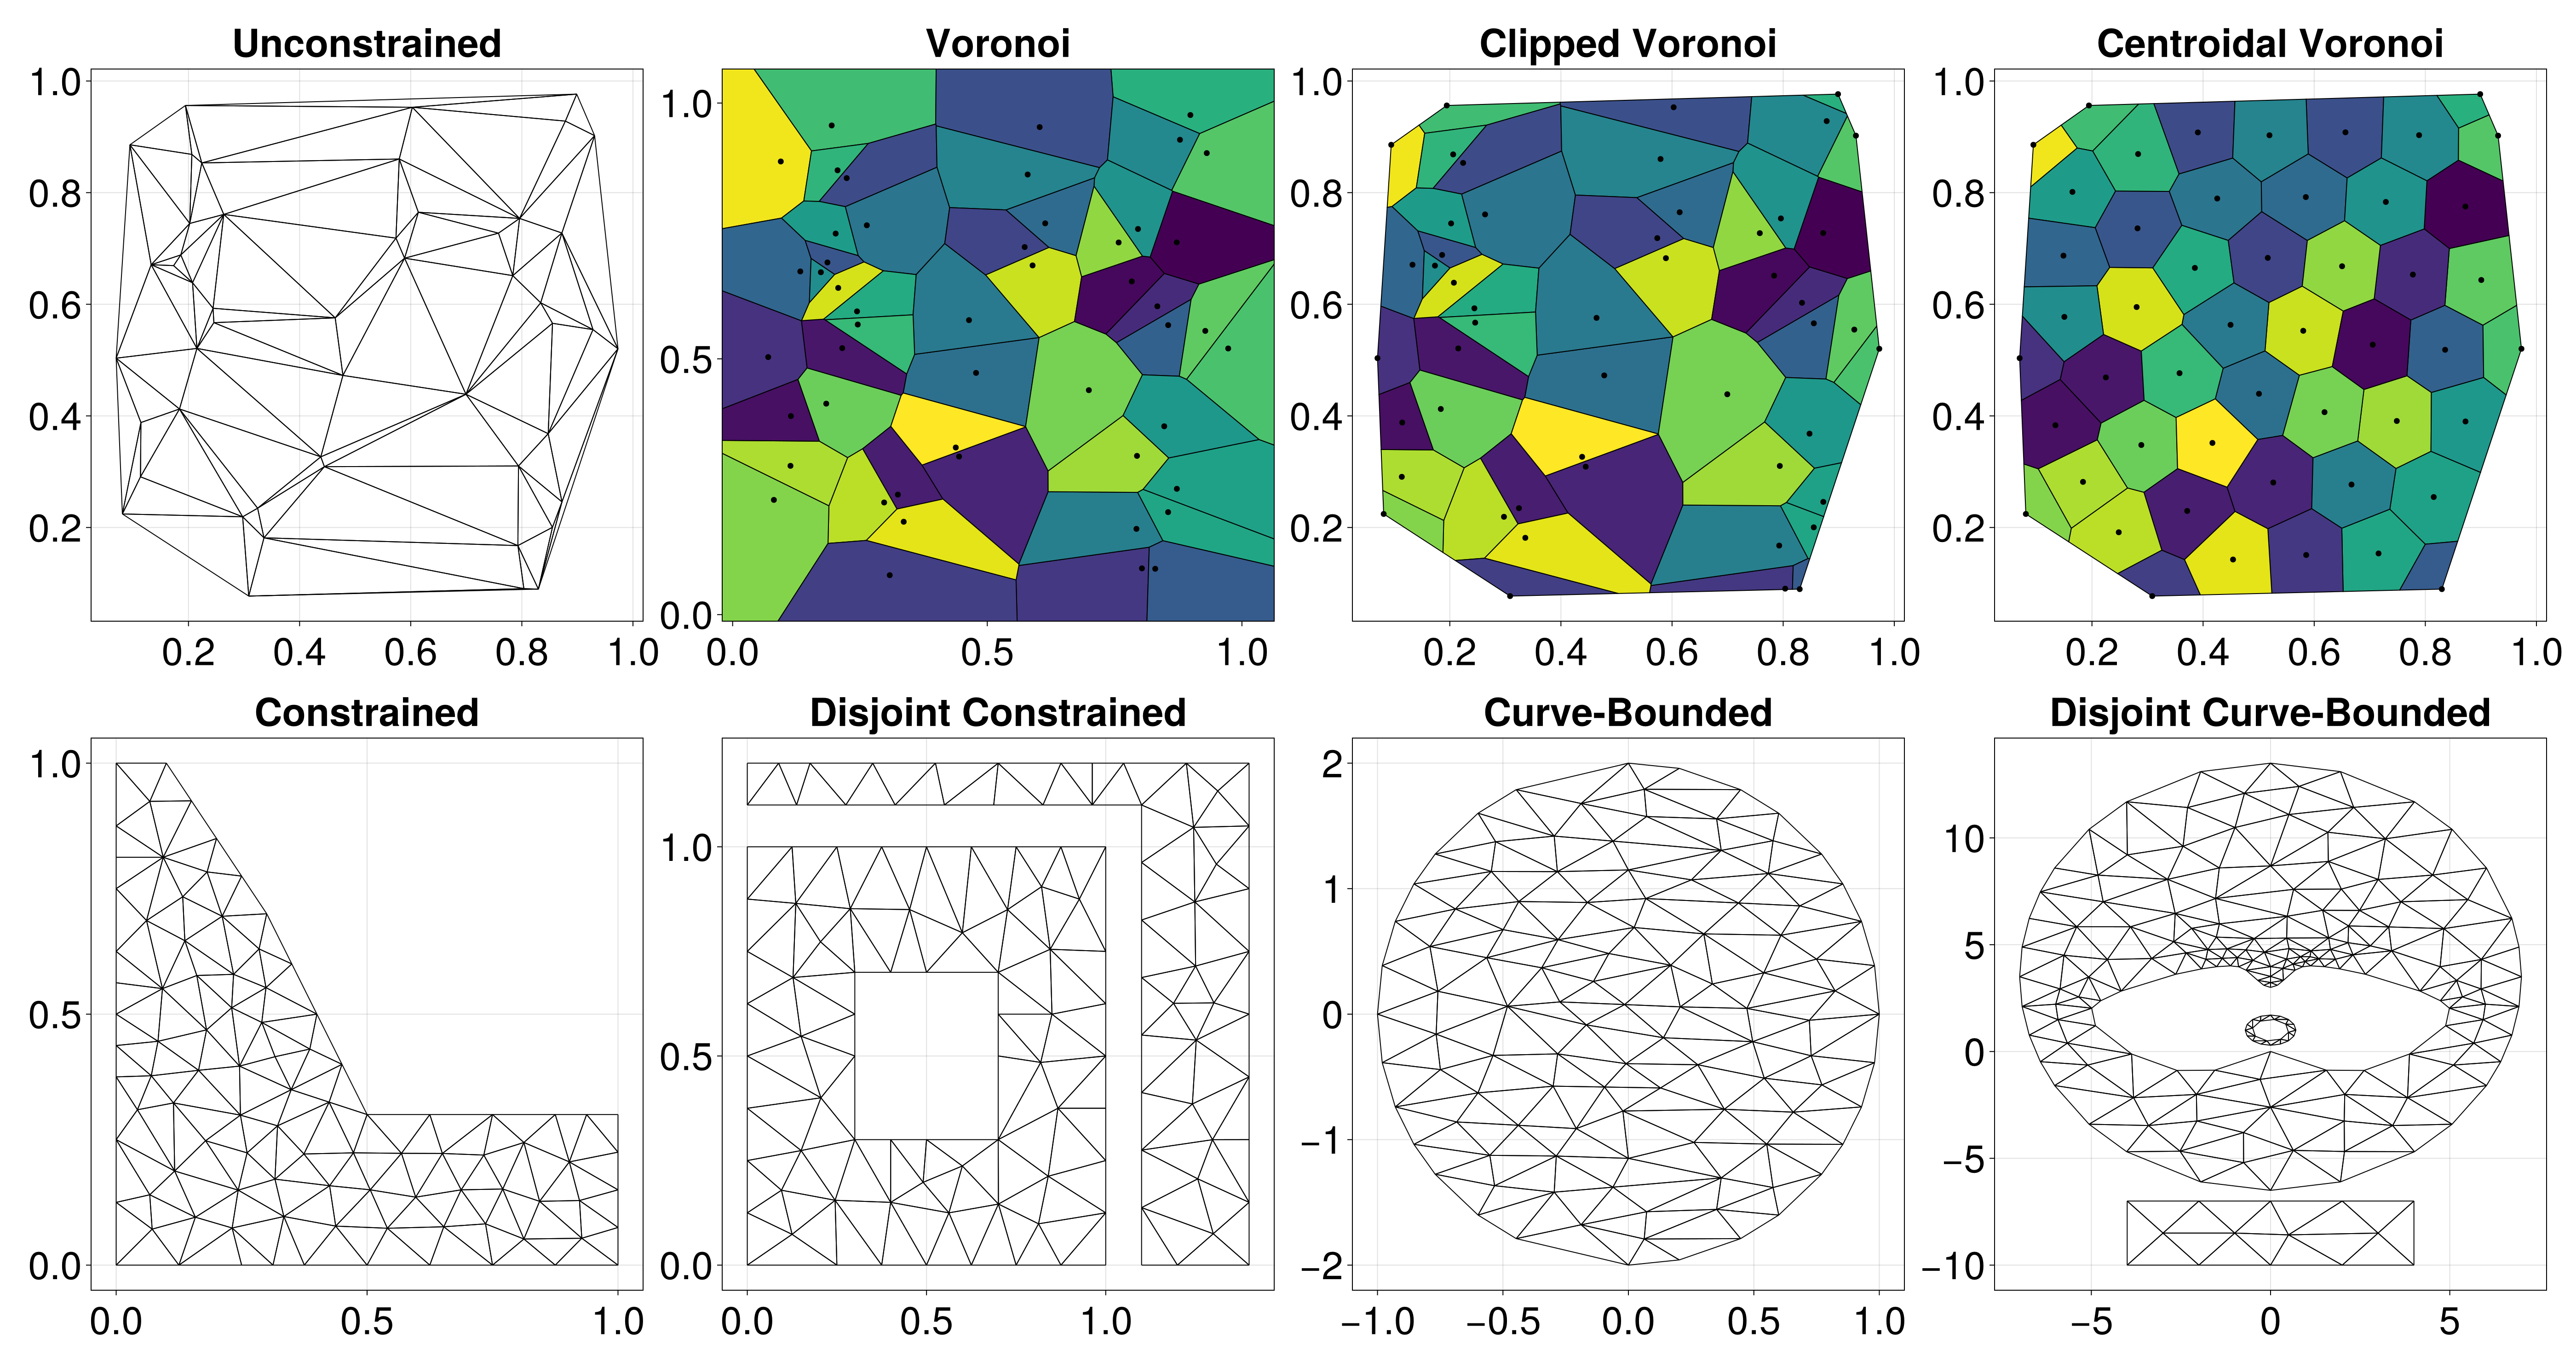

In [14]:
fig